In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) Data Import & Setup

In [ ]:
df = pd.read_csv('social_media_engagement_5000.csv')

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df['posted_at'] = pd.to_datetime(df['posted_at'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
# 2) Data Cleaning

In [ ]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df['gender'] = df['gender'].str.lower().str.strip()

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df = df[df['likes']>=0]
df = df[df['comments']>=0]
df = df[df['shares']>=0]

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df['hashtag_count'] = df['hashtags'].str.count('#')

In [ ]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
# 3)  Data Exploration using Pandas

In [ ]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
df['gender'].value_counts()

,count
gender,
male,1849
other,1581
female,1570


In [ ]:
df['gender'].unique()

array(['female', 'male', 'other'], dtype=object)

In [ ]:
df['gender'].nunique()

3

In [ ]:
df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [ ]:
df['post_type'].nunique()

4

In [ ]:
df['post_category'].value_counts()

,count
post_category,
fitness,675
tech,665
music,635
education,631
lifestyle,607
travel,600
fashion,594
food,593


In [ ]:
df['post_category'].unique()

array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
       'education', 'music'], dtype=object)

In [ ]:
df['post_category'].nunique()

8

In [ ]:
df['device_type'].value_counts()

,count
device_type,
mobile,1684
tablet,1658
desktop,1658


In [ ]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [ ]:
df['device_type'].nunique()

3

In [ ]:
df['country'].value_counts()

,count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
UK,493
Australia,493
Germany,490


In [ ]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
df['country'].nunique()

10

In [ ]:
df.corr(numeric_only=True)

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016200,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016200,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


In [ ]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [ ]:
df.groupby('country')['impression_count'].sum()

,impression_count
country,
Australia,23834767
Brazil,24793360
Canada,24984716
France,25656926
Germany,23816649
India,28067377
Japan,23418816
UAE,24610992
UK,25201861


In [ ]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
Australia,48346.383367
Brazil,49193.174603
Canada,48703.150097
France,51727.673387
Germany,48605.406122
India,52462.386916
Japan,49616.135593
UAE,48928.413519
UK,51119.393509


In [ ]:
# 4) Data Wrangling

In [ ]:
df['engagement_score'] = df['likes'] + df['comments'] +df['shares']

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,...,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,...,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151.0
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896.0


In [ ]:
df['hashtag_count'] = df['hashtags'].str.count('#')

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,...,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,...,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151.0
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896.0


In [ ]:
df.groupby('post_type')[['likes','comments','shares']].mean()

,likes,comments,shares
post_type,,,
image,10104.865277,1525.235766,1019.289495
reel,10037.802416,1504.187062,982.042089
text,10100.148193,1499.106024,1013.989558
video,10188.600000,1479.160000,996.834286


In [ ]:
df.groupby('country')['impression_count'].sum()

,impression_count
country,
Australia,23834767
Brazil,24793360
Canada,24984716
France,25656926
Germany,23816649
India,28067377
Japan,23418816
UAE,24610992
UK,25201861


In [ ]:
df.groupby('sentiment')[['likes','comments','shares']].mean()

,likes,comments,shares
sentiment,,,
negative,10208.096875,1516.094792,1007.307292
neutral,9923.194499,1528.404060,996.565160
positive,10180.062077,1480.650617,1005.086749


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,...,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,...,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151.0
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896.0


In [ ]:
columns = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

In [ ]:
df[columns].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
df[columns].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
df[columns].mode().iloc[0]

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [ ]:
df[columns].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
df[columns].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
df[columns].quantile([0.25, 0.5, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
df[columns].skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
df[columns].kurtosis()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


In [ ]:
# 6) Data Visualization
# Matplotlib

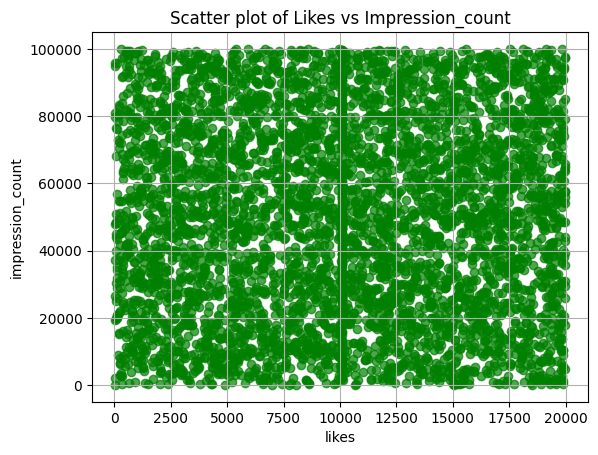

In [ ]:
#Scatter plot
plt.scatter(df['likes'],df['impression_count'],color='green',alpha=0.7)
plt.xlabel('likes')
plt.ylabel('impression_count')
plt.title('Scatter plot of Likes vs Impression_count')
plt.grid(True)
plt.show()

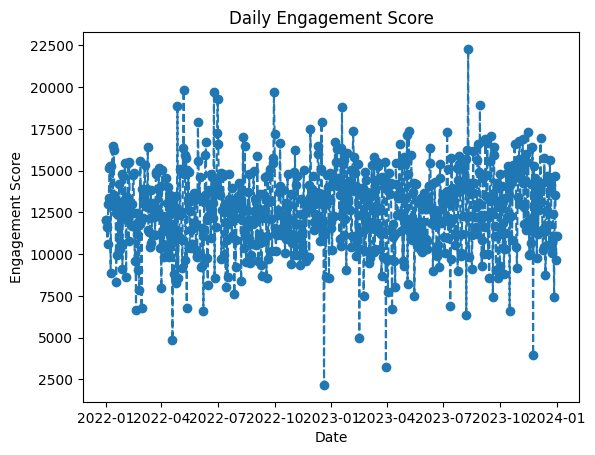

In [ ]:
# Line chart
daily = df.groupby('posted_at')['engagement_score'].mean()
plt.plot(daily.index,daily.values, marker='o', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Engagement Score')
plt.title('Daily Engagement Score')
plt.show()

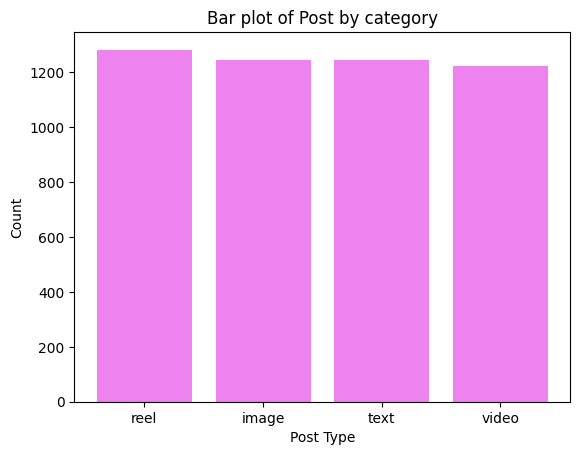

In [ ]:
# Bar plot
post_type_counts = df['post_type'].value_counts()
plt.bar(post_type_counts.index, post_type_counts.values, color='violet')
plt.title('Bar plot of Post by category')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

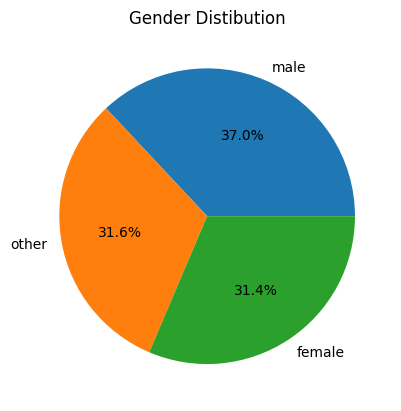

In [ ]:
# Pie Chart
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.1f%%')
plt.title('Gender Distibution')
plt.show()

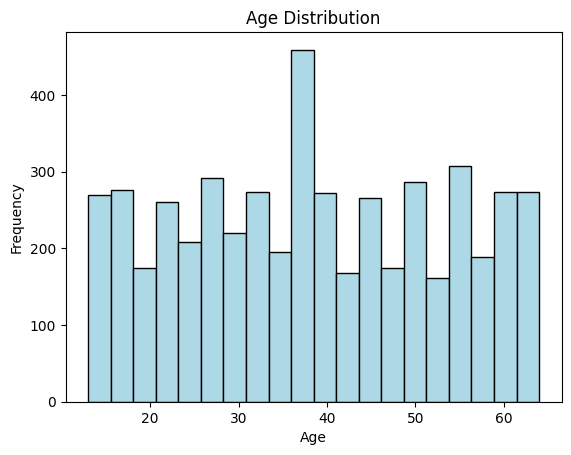

In [ ]:
# Histogram
plt.hist(df['age'],bins=20,color='lightblue',edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

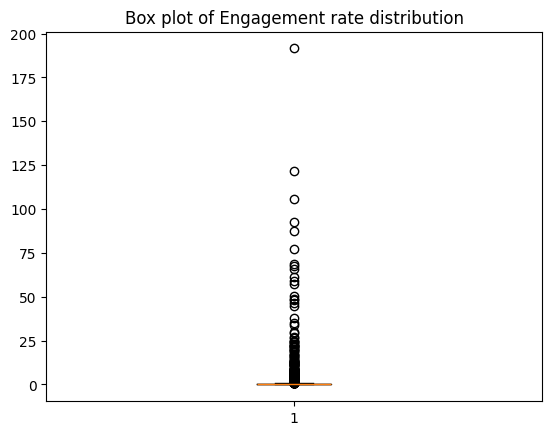

In [ ]:
# Box Plot
plt.boxplot(df['engagement_rate'])
plt.title('Box plot of Engagement rate distribution')
plt.show()

In [ ]:
# 6) Data Visualization
# Seaborn

/tmp/ipykernel_4635/1831096511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='post_type',data=df,palette='pastel')


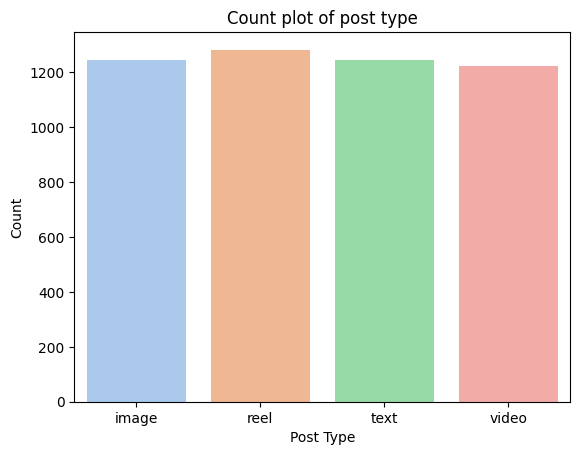

In [ ]:
# Count Plot
sns.countplot(x='post_type',data=df,palette='pastel')
plt.title('Count plot of post type')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_4635/1131389312.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='post_type',y='likes',data=df,palette='pastel')


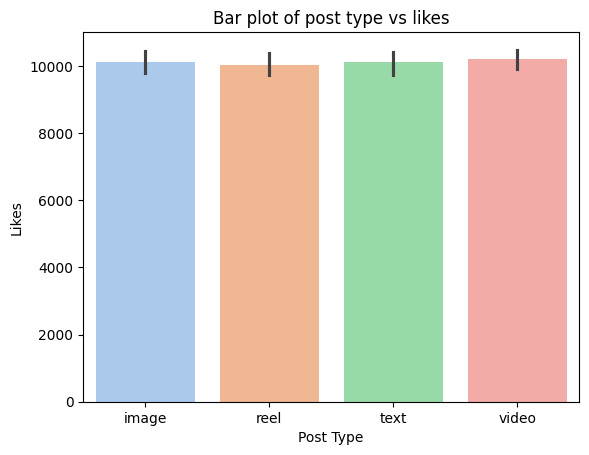

In [ ]:
#Bar Plot
sns.barplot(x='post_type',y='likes',data=df,palette='pastel')
plt.xlabel('Post Type')
plt.ylabel('Likes')
plt.title('Bar plot of post type vs likes')
plt.show()

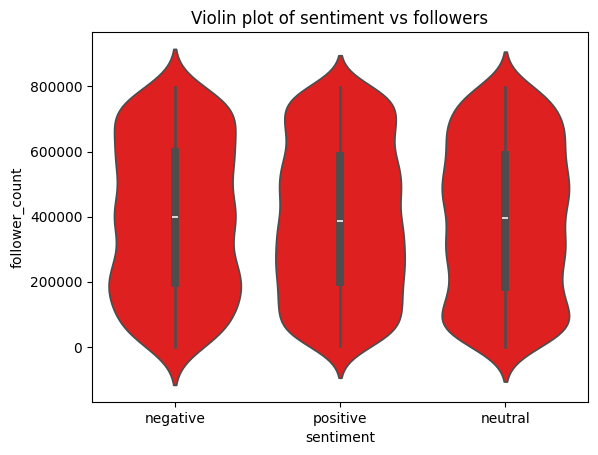

In [ ]:
# Violin Plot
sns.violinplot(x='sentiment',y='follower_count', data=df,color='red')
plt.title('Violin plot of sentiment vs followers')
plt.show()

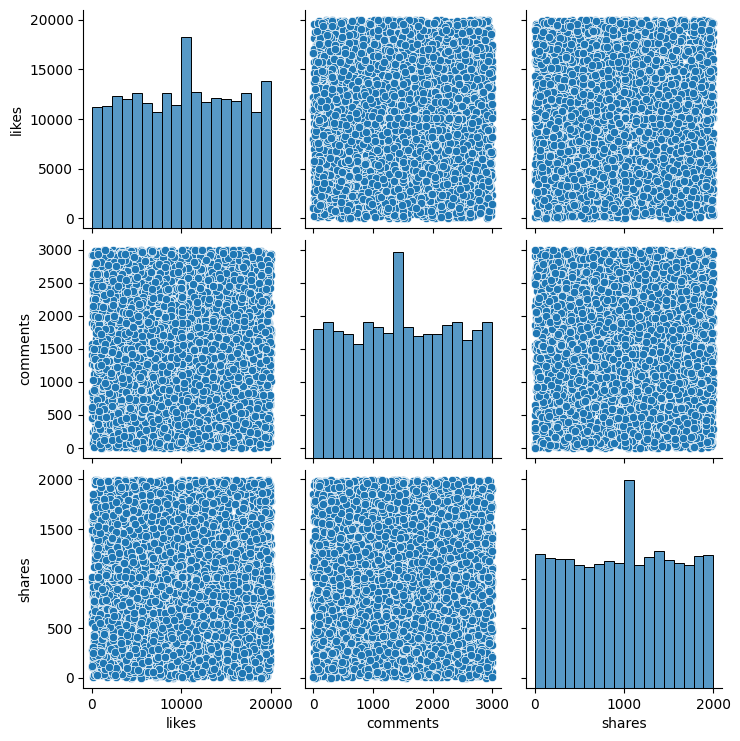

In [ ]:
# Pair plot
sns.pairplot(df[['likes','comments','shares']])
plt.show()

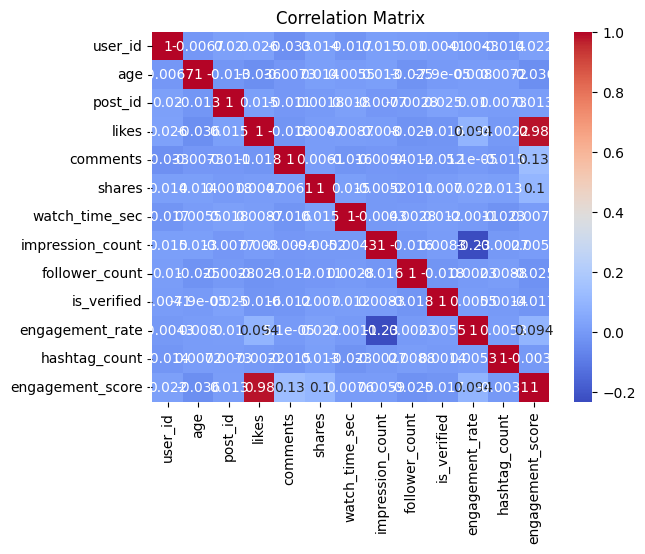

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 52.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.8% of the points cannot be plac

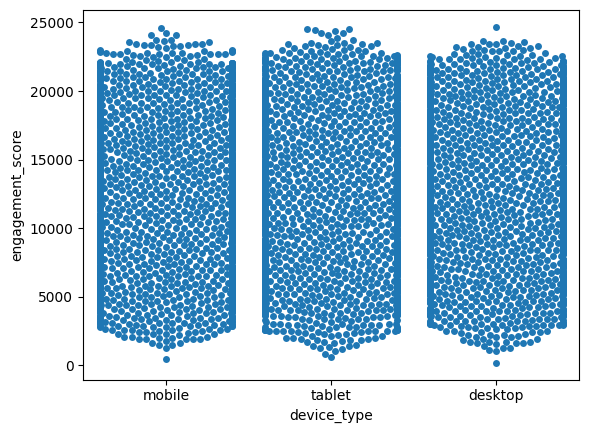

In [ ]:
# Swarm Plot
sns.swarmplot(x='device_type',y='engagement_score',data=df)
plt.show()

In [ ]:
# Plotly
# Interactive line chart
import plotly.express as px
fig = px.line(df, x='posted_at',y='engagement_score',title='Engagemt Over Time')
fig.show()

In [ ]:
# Interactive Scatter plot
fig = px.scatter(df,x='likes',y='impression_count',title='Likes vs Comments')
fig.show()

In [ ]:
# Interactive bubble chart
fig = px.scatter(df,x='likes',y='impression_count',size='follower_count',color='post_type',title='Bubble chart')
fig.show()

In [ ]:
# 7) Final Insights should include the following analysis

In [ ]:
# 1.Content Performance
df.groupby('post_type')['engagement_score'].mean().sort_values(ascending=False)

,engagement_score
post_type,
video,12664.594286
image,12649.390537
text,12613.243775
reel,12524.031567


In [ ]:
# Explanation:"Video posts have the highest engagement,indicating users interact more with video content compared to images or text".

In [ ]:
df.groupby('post_type')['likes'].mean().sort_values(ascending=False)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [ ]:
# Explanation: "Posts related to Video perform best in terms of likes,suggesting audience preference for this content type".

In [ ]:
df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [ ]:
# Explanation: "Brazil shows the highest average engagement rate, indicating stronger audience interaction in this region."

In [ ]:
# 2.User Trends
df.groupby('age')['engagement_score'].mean()

,engagement_score
age,
13.0,12718.036585
14.0,13469.014706
15.0,12830.110465
16.0,12235.698864
17.0,14156.450000
18.0,12474.943878
19.0,11867.058511
20.0,13075.777778
21.0,12447.350575


In [ ]:
# Explanation: "Users aged 20-35 show higher engagement, indicating this age group is the most active audience."

In [ ]:
df.groupby('is_verified')['engagement_score'].mean()

,engagement_score
is_verified,
False,12644.311822
True,12309.280538


In [ ]:
# Explanation: "Verified accounts have lesser angagement.This might suggest that unverified users are putting more effort into content creation to gain traction, or it could be a nuance in the dataset."

In [ ]:
# 3. Behavioral Insights
df['hour'] = df['posted_at'].dt.hour
df.groupby('hour')['impression_count'].mean().sort_values(ascending=False)


,impression_count
hour,
0,50013.7328


In [ ]:
# Explanation: "Posts published around 0 hour receive the highest impressions, making it the optimal posting time."

In [ ]:
df.groupby('device_type')['watch_time_sec'].mean()

,watch_time_sec
device_type,
desktop,3974.792521
mobile,4087.830760
tablet,3979.736429


In [ ]:
# Explanation: "Users on mobile devices show higher watch time,indicating mobile is the dominant platform."

In [ ]:
# 4. Sentiment Analysis
df.groupby('sentiment')['engagement_score'].mean()

,engagement_score
sentiment,
negative,12731.498958
neutral,12448.163720
positive,12665.799443


In [ ]:
# Explanation: "Negative sentiment posts receive higher engagement compared to positive and neutral posts."

In [ ]:
df.groupby('sentiment')[['likes','comments','shares']].mean()

,likes,comments,shares
sentiment,,,
negative,10208.096875,1516.094792,1007.307292
neutral,9923.194499,1528.404060,996.565160
positive,10180.062077,1480.650617,1005.086749


In [ ]:
# Explanation: "Negative sentiment posts receive higher likes, comments and shares."